In [1]:
import logging

import shap

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)
shap.initjs()

In [2]:
from darts.datasets import AirPassengersDataset
from darts.explainability import TorchExplainer
from darts.models import NLinearModel

series = AirPassengersDataset().load().astype("float32")
model = NLinearModel(
    input_chunk_length=13,
    output_chunk_length=12,
    n_epochs=10,
)
model.fit(series[:-36])
shap_explain = TorchExplainer(model)

INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 84 samples.
INFO:darts.models.forecasting.torch_forecasting_model:Time series values are 32-bits; casting model to float32.
INFO: GPU available: True (mps), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricColl

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


Background X shape: (96, 13)


In [3]:
results = shap_explain.explain()

/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


  0%|          | 0/96 [00:00<?, ?it/s]

INFO:shap:num_full_subsets = 3
INFO:shap:remaining_weight_vector = array([0.3626943 , 0.32642487, 0.31088083])
INFO:shap:num_paired_subset_sizes = 6
INFO:shap:weight_left = np.float64(0.32084025993652715)
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999996)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0)
INFO:shap:phi = array([ -6.07210662,  -6.40665979,  -6.01951159,  -6.02155633,
        -6.52202248,   0.        ,   0.        ,   0.        ,
        -6.10757126,  -7.02836254,  -7.6840694 ,  -7.42743362,
       -52.22423885])
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999996)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0)
INFO:shap:phi = array([ -6.17326248,  -7.01939369,  -9.18282562,  -8.50584585,
        -7.42026473,   0.        ,   0.        ,   0.        ,
        -6.3586027 ,  -7.23652695,  -7.77546014,  -7.56534888,
       -40.87714148])
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999996)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0)
INFO:

In [4]:
results.get_explanation(horizon=1)

,#Passengers_target_lag-13,#Passengers_target_lag-12,#Passengers_target_lag-11,#Passengers_target_lag-10,#Passengers_target_lag-9,...,#Passengers_target_lag-5,#Passengers_target_lag-4,#Passengers_target_lag-3,#Passengers_target_lag-2,#Passengers_target_lag-1
1950-02-01,-6.072107,-6.406660,-6.019512,-6.021556,-6.522022,...,-6.107571,-7.028363,-7.684069,-7.427434,-52.224239
1950-03-01,-6.131774,-5.632339,-5.995312,-6.451521,0.000000,...,-6.813242,-7.830020,-7.298301,-7.329374,-47.455217
1950-04-01,0.000000,-6.007465,-6.839139,-5.308009,0.000000,...,-7.644765,-6.813725,-7.186796,-6.842528,-41.579646
1950-05-01,0.000000,-6.337487,-5.839790,0.000000,0.000000,...,-6.892363,-7.151309,-6.681242,-6.030882,-44.216435
1950-06-01,-5.729311,0.000000,0.000000,0.000000,-5.712315,...,-7.001646,-6.582797,-6.048819,-6.274290,-48.241583
...,...,...,...,...,...,...,...,...,...,...,...
1957-09-01,10.614621,8.726796,5.706182,0.000000,0.000000,...,6.605711,6.711650,10.053333,11.963560,88.784705
1957-10-01,7.857365,5.924296,0.000000,0.000000,5.958265,...,7.151450,10.121757,12.144043,12.351326,64.001712
1957-11-01,0.000000,0.000000,6.060679,6.074505,0.000000,...,10.487192,11.959704,12.396726,9.205614,41.502844
1957-12-01,0.000000,0.000000,6.410577,0.000000,8.204530,...,12.254717,12.388122,9.082133,6.323170,25.569508


In [5]:
shap_explain.force_plot_from_ts()

/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


  0%|          | 0/96 [00:00<?, ?it/s]

INFO:shap:num_full_subsets = 3
INFO:shap:remaining_weight_vector = array([0.3626943 , 0.32642487, 0.31088083])
INFO:shap:num_paired_subset_sizes = 6
INFO:shap:weight_left = np.float64(0.32084025993652715)
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999998)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0000000000000002)
INFO:shap:phi = array([ -6.3399714 ,  -6.4216207 ,  -5.88126508,  -5.99376133,
        -6.27401046,   0.        ,   0.        ,   0.        ,
        -6.15060358,  -7.08372369,  -7.85790213,  -7.43604837,
       -52.07462574])
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999998)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0000000000000002)
INFO:shap:phi = array([ -6.46458219,  -7.03382285,  -9.04659004,  -8.46592615,
        -7.15467793,   0.        ,   0.        ,   0.        ,
        -6.40417289,  -7.29609742,  -7.95683175,  -7.56978349,
       -40.72218779])
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999998)
INFO:shap:np.sum(self.kernelWe

  0%|          | 0/96 [00:00<?, ?it/s]

INFO:shap:num_full_subsets = 3
INFO:shap:remaining_weight_vector = array([0.3626943 , 0.32642487, 0.31088083])
INFO:shap:num_paired_subset_sizes = 6
INFO:shap:weight_left = np.float64(0.32084025993652715)
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999998)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0000000000000002)
INFO:shap:phi = array([-1.42140082,  0.        ,  0.        ,  1.16918821, -0.59597832,
       -1.57779912, -2.6637256 , -1.75565616, -1.82522745, -1.95181755,
        0.        , -0.28478255, -5.94447958])
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999998)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0000000000000002)
INFO:shap:phi = array([-1.36767197,  0.        ,  0.        ,  1.88663135, -0.63403999,
       -1.61346858, -2.66677136, -1.72994503, -1.82300567, -1.93292888,
        0.        , -0.25326578, -4.56376078])
INFO:shap:np.sum(w_aug) = np.float64(12.999999999999998)
INFO:shap:np.sum(self.kernelWeights) = np.float64(1.0000000000000002)


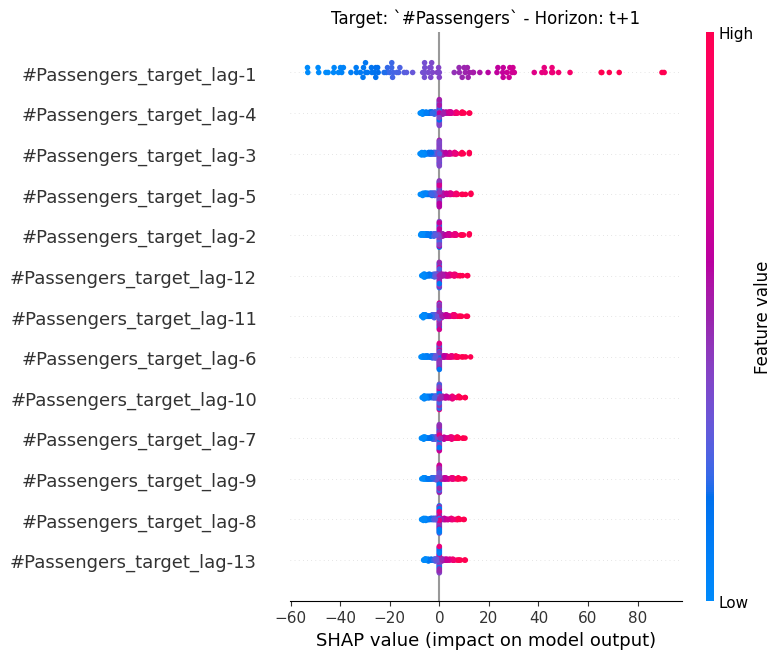

In [8]:
shap_explain.summary_plot(horizons=1);

In [6]:
series[:-36]

,#Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
...,...
1957-08-01,467.0
1957-09-01,404.0
1957-10-01,347.0


In [7]:
results.get_feature_values(horizon=1)

,#Passengers_target_lag-13,#Passengers_target_lag-12,#Passengers_target_lag-11,#Passengers_target_lag-10,#Passengers_target_lag-9,...,#Passengers_target_lag-5,#Passengers_target_lag-4,#Passengers_target_lag-3,#Passengers_target_lag-2,#Passengers_target_lag-1
1950-02-01,112.0,118.0,132.0,129.0,121.0,...,136.0,119.0,104.0,118.0,115.0
1950-03-01,118.0,132.0,129.0,121.0,135.0,...,119.0,104.0,118.0,115.0,126.0
1950-04-01,132.0,129.0,121.0,135.0,148.0,...,104.0,118.0,115.0,126.0,141.0
1950-05-01,129.0,121.0,135.0,148.0,148.0,...,118.0,115.0,126.0,141.0,135.0
1950-06-01,121.0,135.0,148.0,148.0,136.0,...,115.0,126.0,141.0,135.0,125.0
...,...,...,...,...,...,...,...,...,...,...,...
1957-09-01,405.0,355.0,306.0,271.0,306.0,...,348.0,355.0,422.0,465.0,467.0
1957-10-01,355.0,306.0,271.0,306.0,315.0,...,355.0,422.0,465.0,467.0,404.0
1957-11-01,306.0,271.0,306.0,315.0,301.0,...,422.0,465.0,467.0,404.0,347.0
1957-12-01,271.0,306.0,315.0,301.0,356.0,...,465.0,467.0,404.0,347.0,305.0
